<a href="https://colab.research.google.com/github/fatoufall737/atelier-tensorflow-iot/blob/main/atelier_tensorflow_iot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

Partie 1 – Génération du dataset
1) Générer aléatoirement 1000 valeurs pour chacune des variables suivantes :
a) temperature : valeurs qui suivent une loi normale avec une moyenne de 25 °C et un
écart-type de 4 °C.
b) humidite : valeurs réparties de façon uniforme entre 30 % et 80 %.
c) occupants : valeurs entières choisies entre 1 et 49 inclus.
2) Déterminer la variable consommation avec la formule suivante :
 la consommation de base (0 °C, pas d'humidité et pièce vide) est de 50
 chaque degré supplémentaire augmente la consommation de 5 unités
 chaque pourcentage d'humidité en plus ajoute 1,5 unité à la consommation
 chaque personne présente dans la pièce augmente la consommation de 4 unités
 dans la vraie vie, une formule mathématique parfaite n'existe pas. On ajoute donc une
petite variation aléatoire (moyenne de 0 et écart-type de 10) pour simuler des imprévus
ou d'autres facteurs non mesurés.
3) Rassembler les variables (temperature, humidite et occupants) dans la matrice des
caractéristiques (features) X de taille 1000x3 en convertissant éventuellement les données au
format (float32) optimisé pour les calculs
4)  Créer la cible (target) y qui contiendra la variable consommation, au format float32

In [4]:
#Question 1
#a : génère 1000 valeurs de température (loi normale, moyenne 25°C, écart-type 4°C).
np.random.seed(42)  # pour la reproductibilité
n = 1000
temperature = np.random.normal(loc=25, scale=4, size=n)
temperature[:5]

array([26.98685661, 24.4469428 , 27.59075415, 31.09211943, 24.0633865 ])

In [5]:
#b : génère 1000 valeurs d'humidité (réparties uniformément entre 30% et 80%).
humidite = np.random.uniform(low=30, high=80, size=n)
humidite[:5]

array([38.37412911, 35.22839202, 61.82151248, 65.32378632, 31.57930724])

In [6]:
#c : génère 1000 valeurs d'occupants (entiers entre 1 et 49 inclus).
occupants = np.random.randint(low=1, high=50, size=n)
occupants[:5]

array([ 8, 43, 20, 33, 26])

In [7]:
#question 2 : détermine la variable consommation avec la formule donnée.
bruit = np.random.normal(loc=0, scale=10, size=n)

consommation = 50 + (5 * temperature) + (1.5 * humidite) + (4 * occupants) + bruit
consommation[:5]

array([281.62608854, 406.67868707, 348.62841819, 433.63621523,
       318.9414931 ])

In [8]:
#Question 3 : rassemble temperature, humidite, occupants dans la matrice X (1000x3), en float32.
X = np.column_stack([temperature, humidite, occupants]).astype(np.float32)
print(X.shape)
X[:5]

(1000, 3)


array([[26.986856, 38.37413 ,  8.      ],
       [24.446943, 35.228394, 43.      ],
       [27.590754, 61.821514, 20.      ],
       [31.09212 , 65.323784, 33.      ],
       [24.063387, 31.579308, 26.      ]], dtype=float32)

In [9]:
#Question 4 : crée la cible y (la consommation), en float32.
y = consommation.astype(np.float32)
print(y.shape)
y[:5]

(1000,)


array([281.6261 , 406.67868, 348.62842, 433.63623, 318.9415 ],
      dtype=float32)

Partie 2 – Découpage Train/Test
Diviser le dataset précédent (X et y) en deux ensembles distincts : un pour l'entraînement (train)
et un pour le test (test). Avec les conditions suivantes : 20% des données serviront au test ; garantir
la reproductibilité du découpage.

In [10]:
#Partie 2 : Découpage Train/Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(800, 3) (200, 3)


Partie 3 – Création du modèle
1) Construire un réseau de neurones qui utilise l’architecture séquentielle suivante :
a) couche 1 : 16 neurones avec relu comme fonction d’activation
b) couche 2 : 8 neurones avec relu
c) couche 3 : 1 seul neurone.
2) Afficher un résumé textuel de l'architecture du réseau de neurones.

In [11]:
#question 1 : construis le réseau de neurones avec l'architecture séquentielle demandée.
modele = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu", input_shape=(3,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
#Question 2 (dernière de la Partie 3) : affiche un résumé textuel de l'architecture du réseau.

modele.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

Partie 4 – Compilation du modèle
Compiler le modèle avec une méthode pour ajuster les poids, une fonction permettant de mesurer
l'erreur de prédiction et une métrique permettant de suivre l'erreur absolue moyenne.

In [13]:
## Partie 4 : Compilation du modèle

# : compiler le modèle avec une méthode pour ajuster les poids, une fonction pour mesurer l'erreur de prédiction, et une métrique pour suivre l'erreur absolue moyenne.
modele.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

Partie 5 – Entraînement du modèle
1) Entrainer le modèle avec 20 % des données d'entraînement utilisés pour la validation, 50
passages sur les données et 16 observations traitées à la fois. Sauvegarder, dans la variable
history,  l'historique de l’entraînement  
2) Examiner le contenu de history
3) Se servir de l’historique pour visualiser (graphique) et interpréter l’apprentissage

In [14]:
#Question 1 : entraîner le modèle avec 20% de validation, 50 passages (epochs), et 16 observations par lot (batch).
history = modele.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 136209.0000 - mae: 363.3423 - val_loss: 133904.5938 - val_mae: 360.8491
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 134320.2188 - mae: 360.7739 - val_loss: 130430.8516 - val_mae: 356.1693
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 128648.0625 - mae: 353.1965 - val_loss: 123298.9141 - val_mae: 346.4492
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 119255.9609 - mae: 340.2735 - val_loss: 111804.7344 - val_mae: 330.1795
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 104385.0781 - mae: 318.6492 - val_loss: 93711.5938 - val_mae: 302.5677
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 82319.5078 - mae: 283.0681 - val_loss: 68230.5703 - val_mae: 258.4446
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 54138.5820 - mae: 229.4799 - val_loss: 39288.5859 - val_mae: 196.2729
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26796.6719 - mae: 160.7210 - val_loss

In [15]:
#Question 2 : examine le contenu de history.
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

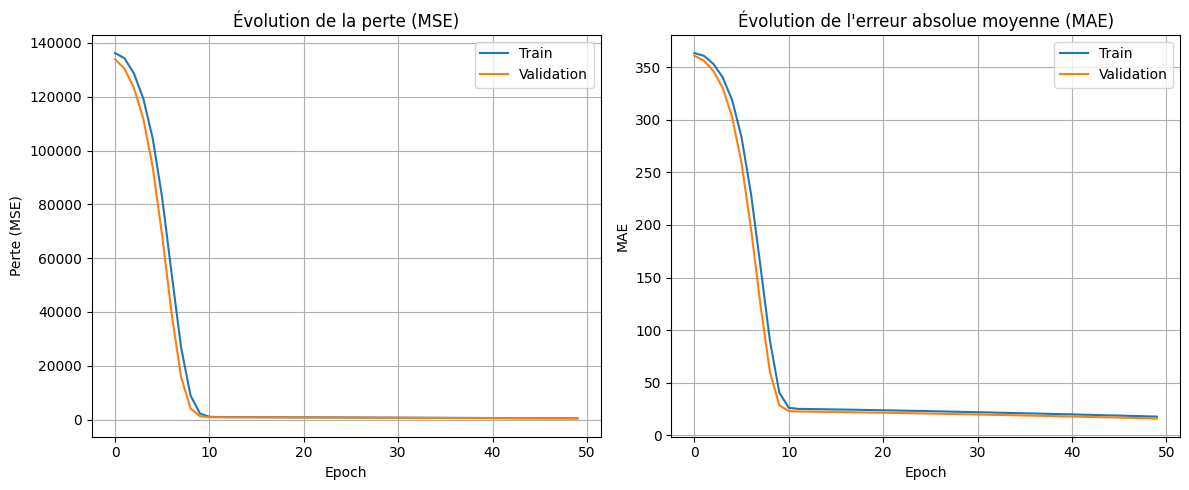

In [16]:
#Question 3 (dernière de la Partie 5) : visualise et interprète l'apprentissage grâce à l'historique.#
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Évolution de la perte (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Perte (MSE)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Train")
plt.plot(history.history["val_mae"], label="Validation")
plt.title("Évolution de l'erreur absolue moyenne (MAE)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**3) Interprétation de l'apprentissage**

Les deux courbes (perte MSE à gauche, MAE à droite) montrent une **forte diminution** au fil des epochs, ce qui signifie que le modèle apprend bien à réduire son erreur de prédiction.

Point important : la courbe de validation (orange) suit de très près la courbe d'entraînement (bleue), sans s'en écarter ni remonter. Cela indique que le modèle **généralise bien** — il n'apprend pas seulement "par cœur" les données d'entraînement (ce qui serait un signe de surapprentissage, où la courbe de validation remonterait alors que celle d'entraînement continue de baisser).

La décroissance rapide dans les premières epochs, suivie d'une stabilisation progressive, est un comportement d'apprentissage classique et sain pour ce type de modèle.

Partie 6 – Evaluation
1) Evaluer le modèle sur les données de test pour récupérer la fonction de perte et la métrique
cible
2) Interpréter les résultats obtenus

In [17]:
#Question 1 : évalue le modèle sur les données de test pour récupérer la fonction de perte et la métrique cible.
test_loss, test_mae = modele.evaluate(X_test, y_test)
print("Perte (MSE) sur le test :", test_loss)
print("MAE sur le test :", test_mae)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 585.1064 - mae: 19.8437  
Perte (MSE) sur le test : 585.1064453125
MAE sur le test : 19.84372901916504


**2) Interprétation des résultats sur le test**

- **MSE (perte) = 585.1** : cette valeur, élevée en apparence, est normale car le MSE élève les erreurs au carré — elle est donc difficile à interpréter directement en unités réelles.
- **MAE = 19.84** : cette valeur est plus parlante — en moyenne, la prédiction du modèle s'écarte de **~19.8 unités** de la vraie consommation. Vu l'échelle de la consommation générée (base 50 + jusqu'à ~5×température + ~1.5×humidité + ~4×occupants, donc des valeurs pouvant aller de quelques dizaines à plusieurs centaines), une erreur moyenne de ~20 reste raisonnable, sans être négligeable.
- Le fait que le MAE sur le test (19.84) soit **proche** du MAE final observé sur validation (visible sur la courbe de la Partie 5) confirme que le modèle généralise correctement — il n'y a pas d'écart important entre performance sur les données déjà vues (entraînement/validation) et sur des données totalement nouvelles (test).